Enter the path to test image: /content/faces/OIP (2).jpg


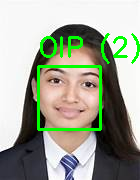

In [6]:
# exp 5
!pip install face_recognition opencv-python

import face_recognition
import cv2
import os
import numpy as np
from google.colab.patches import cv2_imshow # Import cv2_imshow

# Lists to store known faces
known_face_encodings = []
known_face_names = []

# Path where all images are stored
dataset_path = "faces"

# Load each image from the folder
for image_name in os.listdir(dataset_path):
    image_path = os.path.join(dataset_path, image_name)

    # Load image
    image = face_recognition.load_image_file(image_path)

    # Encode face
    encoding = face_recognition.face_encodings(image)[0]

    # Extract student name from filename
    student_name = os.path.splitext(image_name)[0]

    known_face_encodings.append(encoding)
    known_face_names.append(student_name)

# Load test image
test_image_path = input("Enter the path to test image: ")
test_image = face_recognition.load_image_file(test_image_path)

# Detect faces
face_locations = face_recognition.face_locations(test_image)
face_encodings = face_recognition.face_encodings(test_image, face_locations)

# Convert image for display
image_bgr = cv2.cvtColor(test_image, cv2.COLOR_RGB2BGR)

# Recognize faces
for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
    matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
    name = "Unknown"

    if True in matches:
        first_match_index = matches.index(True)
        name = known_face_names[first_match_index]

    cv2.rectangle(image_bgr, (left, top), (right, bottom), (0, 255, 0), 2)
    cv2.putText(image_bgr, name, (left, top - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

cv2_imshow(image_bgr)
# cv2.waitKey(0)
# cv2.destroyAllWindows()